<a href="https://colab.research.google.com/github/ariel07-sw/applied-data-in-econ/blob/main/Assignment_4/Assignment_4_The_Predictive_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.


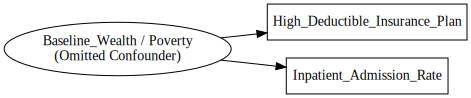

In [1]:
!pip install graphviz
!apt-get install graphviz -y

from graphviz import Digraph
from IPython.display import display

dag = Digraph(format='png')
dag.attr(rankdir='LR', size='8,5')

dag.node('C', 'Baseline_Wealth / Poverty\n(Omitted Confounder)', shape='ellipse')
dag.node('X', 'High_Deductible_Insurance_Plan', shape='box')
dag.node('Y', 'Inpatient_Admission_Rate', shape='box')

dag.edge('C', 'X')
dag.edge('C', 'Y')

dag.render('dag_fork_structure', view=False)
display(dag)

Step 1.1 Interpretation:

The omitted confounder is patient baseline wealth (or systemic poverty).
This creates a fork structure in the DAG:

Baseline Wealth / Poverty --> High Deductible Insurance Plan
Baseline Wealth / Poverty --> Inpatient Admission Rate

Why is the regression biased?
If we regress Inpatient_Admission_Rate on High_Deductible_Insurance_Plan
without controlling for baseline wealth/poverty, the insurance coefficient
captures not only the direct effect of insurance type, but also the effect
of the omitted confounder that is correlated with both variables.

This is omitted variable bias:
beta_hat_insurance = beta_insurance + bias

So the positive correlation is spurious and should not be interpreted as causal.


In [3]:
import pandas as pd

df = pd.read_csv('/content/OmniCare_Clinical_Vitals.csv')
print(df.head())
print(df.columns)

   Patient_ID  Height_cm  Weight_kg    BMI  Systolic_BP  Diastolic_BP
0        1000      177.5       66.3  21.06        110.0          75.0
1        1001      167.9       57.5  20.39        115.0          79.0
2        1002      179.7       57.4  17.77        111.0          77.0
3        1003      192.8       80.9  21.76        122.0          88.0
4        1004      166.5       65.7  23.70        138.0          89.0
Index(['Patient_ID', 'Height_cm', 'Weight_kg', 'BMI', 'Systolic_BP',
       'Diastolic_BP'],
      dtype='object')


In [4]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[['Weight_kg', 'Height_cm', 'BMI', 'Systolic_BP', 'Diastolic_BP']].copy()

X_const = sm.add_constant(X)

vif_df = pd.DataFrame()
vif_df['Feature'] = X_const.columns
vif_df['VIF'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

print("Initial VIF results:")
print(vif_df)

Initial VIF results:
        Feature          VIF
0         const  3369.565806
1     Weight_kg    57.428058
2     Height_cm    28.419446
3           BMI    16.981232
4   Systolic_BP     4.219406
5  Diastolic_BP     4.219820


In [5]:
X_reduced = df[['Weight_kg', 'Height_cm', 'Systolic_BP', 'Diastolic_BP']].copy()

X_reduced_const = sm.add_constant(X_reduced)

vif_reduced_df = pd.DataFrame()
vif_reduced_df['Feature'] = X_reduced_const.columns
vif_reduced_df['VIF'] = [
    variance_inflation_factor(X_reduced_const.values, i)
    for i in range(X_reduced_const.shape[1])
]

print("VIF after dropping BMI:")
print(vif_reduced_df)

VIF after dropping BMI:
        Feature         VIF
0         const  321.090128
1     Weight_kg    3.763969
2     Height_cm    3.763812
3   Systolic_BP    4.219406
4  Diastolic_BP    4.219820


In [6]:
!pip install missingno

import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

Shape of dataset: (5000, 8)

Columns:
['Patient_ID', 'High_Deductible_Insurance_Plan', 'Inpatient_Admission_Rate', 'Continuous_Heart_Rate', 'Primary_Diagnosis_Code', 'Clinic_Capacity_Percentage', 'Time_of_Day_Index', 'Procedure_Cost_USD']

Missing values by column:
Patient_ID                           0
High_Deductible_Insurance_Plan       0
Inpatient_Admission_Rate             0
Continuous_Heart_Rate             1214
Primary_Diagnosis_Code               0
Clinic_Capacity_Percentage           0
Time_of_Day_Index                    0
Procedure_Cost_USD                   0
dtype: int64


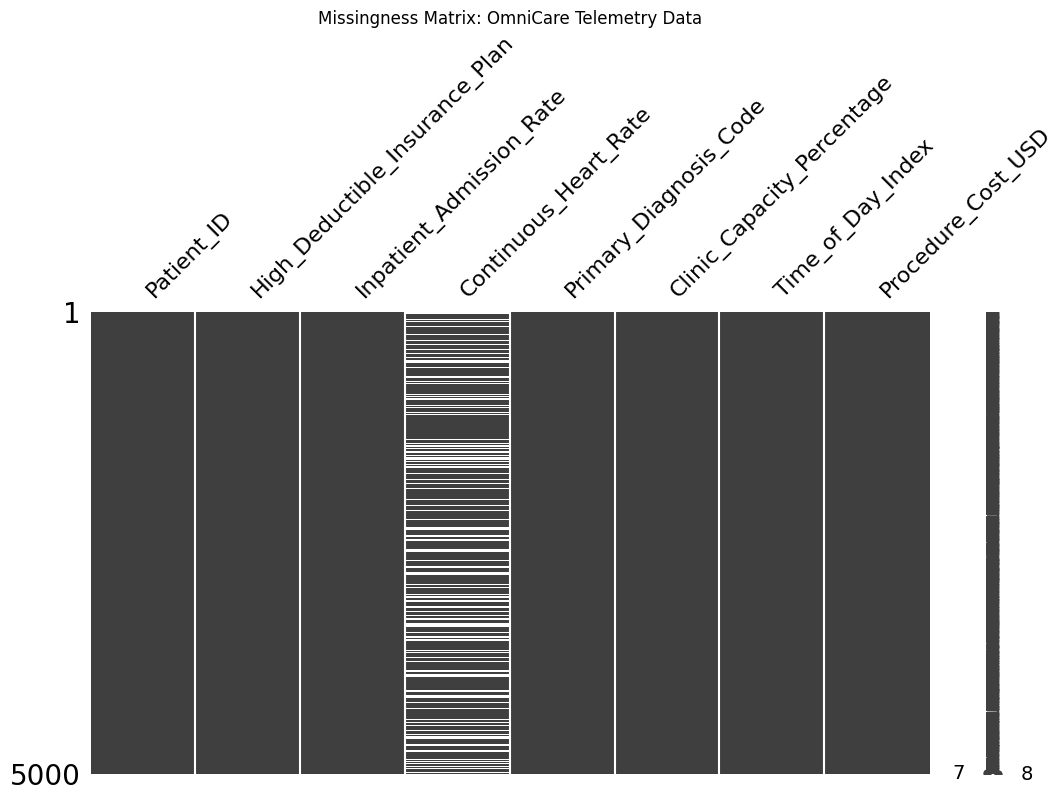

In [7]:
df = pd.read_csv('/content/OmniCare_Telemetry_Data.csv')

print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values by column:")
print(df.isna().sum())

msno.matrix(df, figsize=(12,6))
plt.title("Missingness Matrix: OmniCare Telemetry Data")
plt.show()

In [8]:
missing_rate = df['Continuous_Heart_Rate'].isna().mean()
print(f"Missing rate in Continuous_Heart_Rate: {missing_rate:.2%}")

Missing rate in Continuous_Heart_Rate: 24.28%


Continuous_Heart_Rate             1214
Patient_ID                           0
High_Deductible_Insurance_Plan       0
Inpatient_Admission_Rate             0
Primary_Diagnosis_Code               0
Clinic_Capacity_Percentage           0
Time_of_Day_Index                    0
Procedure_Cost_USD                   0
dtype: int64


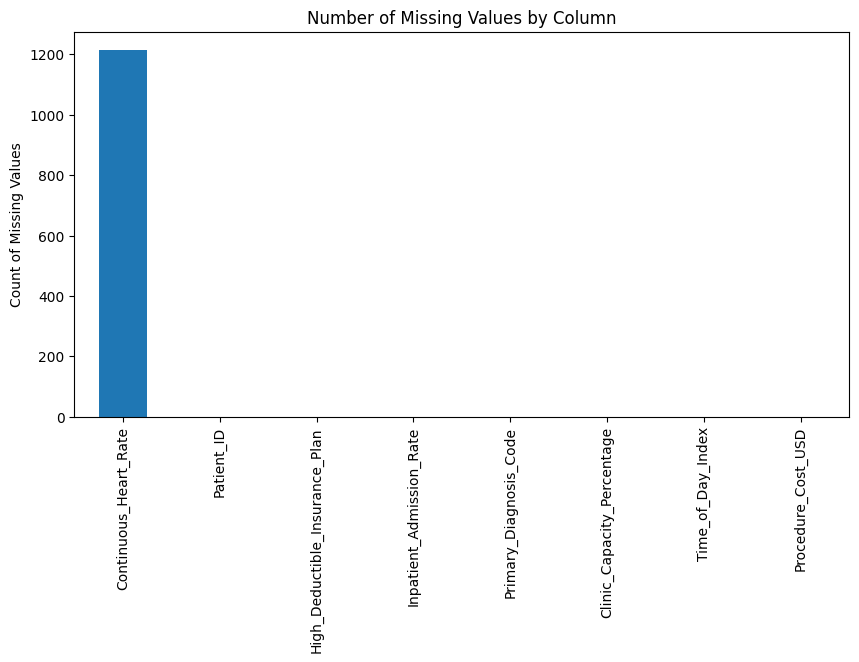

In [9]:
missing_summary = df.isna().sum().sort_values(ascending=False)
print(missing_summary)

missing_summary.plot(kind='bar', figsize=(10,5))
plt.title("Number of Missing Values by Column")
plt.ylabel("Count of Missing Values")
plt.show()

Step 2.1 Interpretation:

The missingness in Continuous_Heart_Rate is best classified as MNAR
(Missing Not At Random), not MCAR.

It is not MCAR because the probability of missingness is not unrelated
to the patient population; instead, it follows a systematic pattern.

It is not safely treated as MAR either, because the missingness mechanism
is driven by an economically selective behavioral process: low-income
patients may refuse to continuously transmit telemetry due to data-plan costs.
This means the missingness is tied to an underlying unobserved mechanism
related to socioeconomic vulnerability and potentially to patient risk itself.

Why is mean imputation inappropriate?
Mean imputation would artificially compress the variance of heart rate,
distort the empirical distribution, attenuate covariance with other predictors,
and falsely suggest that missing patients have 'average' physiological states.
That destroys the integrity of the dataset and masks the structural inequality
that generated the missingness in the first place.

In [10]:
n_unique = df['Primary_Diagnosis_Code'].nunique()
print("Number of unique diagnosis codes:", n_unique)

Number of unique diagnosis codes: 847


In [11]:
dummies_full = pd.get_dummies(df['Primary_Diagnosis_Code'], prefix='DX', drop_first=False)

print("Shape of full dummy matrix:", dummies_full.shape)
print("First few dummy columns:")
print(dummies_full.iloc[:5, :5])

Shape of full dummy matrix: (5000, 847)
First few dummy columns:
   DX_A10.352  DX_A10.603  DX_A10.715  DX_A11.104  DX_A11.268
0       False       False       False       False       False
1       False       False       False       False       False
2       False       False       False       False       False
3       False       False       False       False       False
4       False       False       False       False       False


In [13]:
import numpy as np
import statsmodels.api as sm

# Convert boolean dummies to integers
dummies_full_numeric = dummies_full.astype(int)

# Add intercept
X_full = sm.add_constant(dummies_full_numeric)

# Matrix rank
rank = np.linalg.matrix_rank(X_full.values)
n_cols = X_full.shape[1]

print("Number of columns in X_full:", n_cols)
print("Matrix rank of X_full:", rank)
print("Is the design matrix full rank?", rank == n_cols)

Number of columns in X_full: 848
Matrix rank of X_full: 847
Is the design matrix full rank? False


In [14]:
dummy_row_sum = dummies_full.sum(axis=1)

print("Do all dummy rows sum to 1?")
print((dummy_row_sum == 1).all())

print("\nFirst 10 row sums:")
print(dummy_row_sum.head(10))

Do all dummy rows sum to 1?
True

First 10 row sums:
0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
dtype: int64


In [16]:
dummies_reduced = pd.get_dummies(df['Primary_Diagnosis_Code'], prefix='DX', drop_first=True)

# Convert boolean dummies to integers
dummies_reduced_numeric = dummies_reduced.astype(int)

X_reduced = sm.add_constant(dummies_reduced_numeric)

rank_reduced = np.linalg.matrix_rank(X_reduced.values)
n_cols_reduced = X_reduced.shape[1]

print("Number of columns in reduced X:", n_cols_reduced)
print("Matrix rank of reduced X:", rank_reduced)
print("Is reduced design matrix full rank?", rank_reduced == n_cols_reduced)

Number of columns in reduced X: 847
Matrix rank of reduced X: 847
Is reduced design matrix full rank? True


In [17]:
!pip install category_encoders

import pandas as pd
import category_encoders as ce

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.9 MB/s eta 0:00:00


In [18]:
df = pd.read_csv('/content/OmniCare_Telemetry_Data.csv')

print(df[['Primary_Diagnosis_Code', 'Procedure_Cost_USD']].head())
print("Unique diagnosis codes:", df['Primary_Diagnosis_Code'].nunique())

  Primary_Diagnosis_Code  Procedure_Cost_USD
0                J86.381             1635.84
1                M29.789             1355.77
2                E49.618             1189.19
3                E66.244             1250.93
4                J45.553             1986.34
Unique diagnosis codes: 847


In [19]:
X = df[['Primary_Diagnosis_Code']]
y = df['Procedure_Cost_USD']

encoder = ce.TargetEncoder(cols=['Primary_Diagnosis_Code'])

X_encoded = encoder.fit_transform(X, y)

X_encoded.columns = ['Primary_Diagnosis_Code_TE']

print("First five rows of target-encoded feature:")
print(X_encoded.head())

First five rows of target-encoded feature:
   Primary_Diagnosis_Code_TE
0                1707.697108
1                1792.303198
2                1730.334968
3                1725.060944
4                1801.821085


In [20]:
result = pd.concat([df[['Primary_Diagnosis_Code', 'Procedure_Cost_USD']].head(),
                    X_encoded.head()], axis=1)

print(result)

  Primary_Diagnosis_Code  Procedure_Cost_USD  Primary_Diagnosis_Code_TE
0                J86.381             1635.84                1707.697108
1                M29.789             1355.77                1792.303198
2                E49.618             1189.19                1730.334968
3                E66.244             1250.93                1725.060944
4                J45.553             1986.34                1801.821085


In [21]:
import statsmodels.formula.api as smf
from statsmodels.tools.eval_measures import rmse

In [23]:
vitals = pd.read_csv('/content/OmniCare_Clinical_Vitals.csv')
telemetry = pd.read_csv('/content/OmniCare_Telemetry_Data.csv')

print("Vitals shape:", vitals.shape)
print("Telemetry shape:", telemetry.shape)

print("\nVitals columns:")
print(vitals.columns.tolist())

print("\nTelemetry columns:")
print(telemetry.columns.tolist())

Vitals shape: (5000, 6)
Telemetry shape: (5000, 8)

Vitals columns:
['Patient_ID', 'Height_cm', 'Weight_kg', 'BMI', 'Systolic_BP', 'Diastolic_BP']

Telemetry columns:
['Patient_ID', 'High_Deductible_Insurance_Plan', 'Inpatient_Admission_Rate', 'Continuous_Heart_Rate', 'Primary_Diagnosis_Code', 'Clinic_Capacity_Percentage', 'Time_of_Day_Index', 'Procedure_Cost_USD']


In [24]:
final_df = telemetry.merge(
    vitals[['Patient_ID', 'Weight_kg', 'Height_cm', 'Systolic_BP', 'Diastolic_BP']],
    on='Patient_ID',
    how='left'
)

print("\nMerged dataset shape:", final_df.shape)
print(final_df.head())


Merged dataset shape: (5000, 12)
   Patient_ID  High_Deductible_Insurance_Plan  Inpatient_Admission_Rate  \
0        1000                               1                     0.341   
1        1001                               0                     0.213   
2        1002                               0                     0.166   
3        1003                               1                     0.143   
4        1004                               0                     0.219   

   Continuous_Heart_Rate Primary_Diagnosis_Code  Clinic_Capacity_Percentage  \
0                   76.9                J86.381                        0.63   
1                   79.6                M29.789                        0.71   
2                   92.3                E49.618                        0.76   
3                   79.3                E66.244                        0.52   
4                   75.9                J45.553                        0.65   

   Time_of_Day_Index  Procedure_Cost_USD

In [25]:
encoder = ce.TargetEncoder(cols=['Primary_Diagnosis_Code'])
final_df['Target_Encoded_Diagnosis'] = encoder.fit_transform(
    final_df[['Primary_Diagnosis_Code']],
    final_df['Procedure_Cost_USD']
)

print("\nEncoded diagnosis preview:")
print(final_df[['Primary_Diagnosis_Code', 'Target_Encoded_Diagnosis']].head())


Encoded diagnosis preview:
  Primary_Diagnosis_Code  Target_Encoded_Diagnosis
0                J86.381               1707.697108
1                M29.789               1792.303198
2                E49.618               1730.334968
3                E66.244               1725.060944
4                J45.553               1801.821085


In [26]:
formula = """
Procedure_Cost_USD ~ Target_Encoded_Diagnosis
                   + Clinic_Capacity_Percentage
                   + Time_of_Day_Index
                   + Weight_kg
                   + Height_cm
                   + Systolic_BP
                   + Diastolic_BP
"""

model = smf.ols(formula=formula, data=final_df).fit()

print("\nOLS Summary:")
print(model.summary())


OLS Summary:
                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     228.8
Date:                Sat, 28 Mar 2026   Prob (F-statistic):          6.83e-296
Time:                        02:18:41   Log-Likelihood:                -36162.
No. Observations:                5000   AIC:                         7.234e+04
Df Residuals:                    4992   BIC:                         7.239e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Interc

In [27]:
y_true = final_df['Procedure_Cost_USD']
y_pred = model.predict(final_df)

model_rmse = rmse(y_true, y_pred)

print("\nRMSE:", model_rmse)
print("R-squared:", model.rsquared)


RMSE: 334.80215211463116
R-squared: 0.2428783484078454


An RMSE of $450 for a procedure that typically costs $1,200 implies an average prediction error of about 37.5% of the procedure price. This is operationally and financially dangerous in a live hospital pricing system.

First, such a large error could systematically underprice procedures, causing major revenue leakage and budget instability. Second, it could overprice procedures, exposing patients to unfair billing and increasing the probability of disputes, reputational damage, and reduced trust. Third, because healthcare pricing is heavily regulated, large algorithmic pricing errors may create compliance and legal risks, especially if the errors disproportionately affect vulnerable patient groups. Therefore, even if the model has a moderate R-squared, an RMSE of this size would make deployment highly risky without much stronger validation and governance controls.

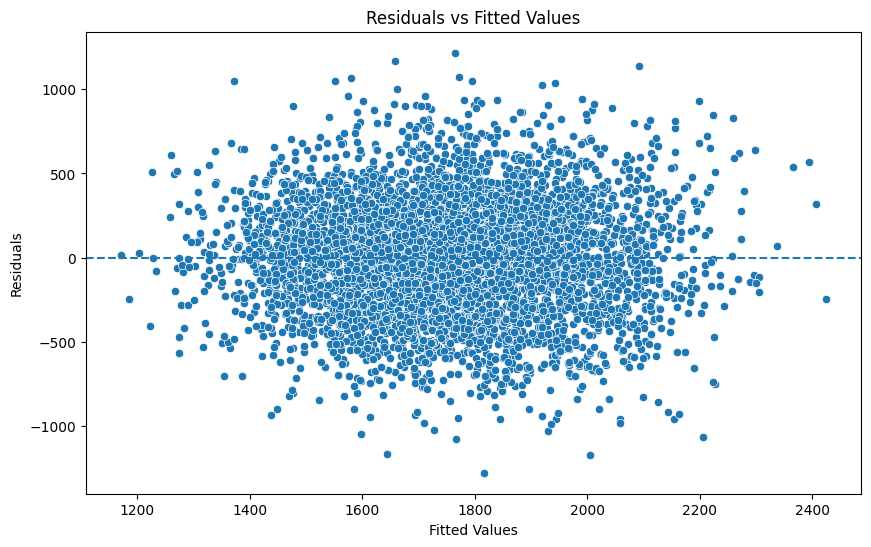

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

fitted_vals = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(10,6))
sns.scatterplot(x=fitted_vals, y=residuals)
plt.axhline(0, linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

Step 3.3 Interpretation

The residual-versus-fitted plot is used to visually assess the homoscedasticity assumption of OLS. If the residuals fan out as the fitted values increase, this indicates heteroscedasticity rather than constant error variance.

In this context, heteroscedasticity means that the model becomes less stable at higher predicted procedure-cost levels. In other words, prediction errors are relatively smaller in low-cost regions but substantially larger in high-cost or surge-pricing tiers. This structural flaw implies that the algorithm is least reliable exactly where pricing decisions are most financially sensitive.

In [29]:
# Step 4.1: White's Lagrange Multiplier Test for Heteroscedasticity

from statsmodels.stats.diagnostic import het_white

# Run White test
white_test = het_white(model.resid, model.model.exog)

# Store results
lm_stat = white_test[0]
lm_pvalue = white_test[1]
f_stat = white_test[2]
f_pvalue = white_test[3]

# Print results
print("White Test Results")
print("------------------")
print("LM Statistic:", lm_stat)
print("LM Test p-value:", lm_pvalue)
print("F-Statistic:", f_stat)
print("F-Test p-value:", f_pvalue)

# Interpretation
if lm_pvalue < 0.05:
    print("\nConclusion: The null hypothesis of homoscedasticity is rejected. There is evidence of heteroscedasticity in the OLS model.")
else:
    print("\nConclusion: The null hypothesis of homoscedasticity is not rejected. There is not sufficient evidence of heteroscedasticity in the OLS model.")

White Test Results
------------------
LM Statistic: 186.46773970660723
LM Test p-value: 1.4380291432919198e-22
F-Statistic: 5.494188406766981
F-Test p-value: 4.4790231228469927e-23

Conclusion: The null hypothesis of homoscedasticity is rejected. There is evidence of heteroscedasticity in the OLS model.


Since the LM test p-value is far below 0.05, the null hypothesis of homoscedasticity is rejected. Therefore, the model exhibits statistically significant heteroscedasticity.